In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Business Task

<p style="text-align: justify">
Cyclistic is a bike-share company that has expanded to a fleet of 5,824 bicycles, geotracked and distributed across 692 stations in Chicago. What sets Cyclistic apart is its inclusive offering of reclining bikes, hand tricycles, and cargo bikes, making bike-share accessible to people with disabilities and riders who cannot use a standard two-wheeled bike. Customers can unlock a bike at one station and return it to any other station in the system at any time.
</p>

<p style="text-align: justify">
Cyclistic’s growth has been supported by flexible pricing plans, including single-ride passes, full-day passes, and annual memberships. To better understand customer behavior, riders are segmented into two groups: casual riders, who purchase single-ride or day passes, and members, who commit to annual memberships.
</p>

<p style="text-align: justify">
An analysis by the finance team revealed a significant difference in profitability between these two groups. Based on this insight, the company believes there is strong potential to convert casual riders into members. Therefore, the goal of this analysis is to understand how casual riders and annual members use Cyclistic bikes differently. By analyzing historical trip data, we aim to identify behavioral patterns across the two groups and generate insights that can help the marketing team design strategies to convert casual riders into annual members. The analysis will focus on ride frequency, trip duration, time-of-day usage, and seasonal patterns.
</p>



# Data Preparation


## Data Source
<p style="text-align:justify">
The datasets used in this case study were obtained from Divvy's public trip data repository:
https://divvy-tripdata.s3.amazonaws.com/index.html
</p>
<p style="text-align:justify">
These files contain Cyclistic's historical trip records including ride duration, rider type, start and end times, and station details. The data was made available for analysis as part of the case study and is used to identify differences between casual riders and annual members.
</p>

## Data Licensing and Accessibility
<p style="text-align:justify">
The data is publicly available under Divvy's Data License Agreement:
https://divvybikes.com/data-license-agreement
</p>
<p style="text-align:justify">
According to the license, the data can be accessed and analyzed for lawful purposes, including use in analyses, reports, or studies for non-commercial purposes. However, the data is provided "as is," which means accuracy, completeness, and availability are not guaranteed.
</p>

## Data Organization
<p style="text-align:justify">
The data is organized in tabular format, with each row representing one bike trip and each column representing a trip attribute such as ride ID, bike type, start time, end time, start station, end station, and member status. Because the data is provided across multiple files, it may need to be combined before analysis.
</p>

## Data Credibility and Bias
<p style="text-align:justify">
The dataset is relevant to the business problem because it contains real trip behavior for both casual riders and members. However, it has some limitations. It does not include personal demographic information, customer motivations, or direct feedback, so conclusions can only be based on trip behavior. In addition, the data may contain missing values, inconsistent station names, or other quality issues that need to be addressed before analysis.
</p>

## Data Integrity
<p style="text-align:justify">
To verify the integrity of the data, the files will be inspected for missing values, duplicate records, incorrect data types, and inconsistent formatting. Column names and data structures will also be reviewed to ensure the datasets can be merged and analyzed correctly.
</p>

## Data Limitations
<p style="text-align:justify">
Although the data is useful for identifying usage patterns, it may not fully explain why casual riders choose not to become members. This means the analysis can support recommendations, but it cannot directly measure customer intent or preferences.
</p>

In [2]:
divvy_trips_19 = pd.read_csv("../data/Divvy_Trips_2019_Q1.csv")
divvy_trips_20 = pd.read_csv("../data/Divvy_Trips_2020_Q1.csv")

In [3]:
divvy_trips_19.head()

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,390.0,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Subscriber,Male,1989.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,441.0,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Subscriber,Female,1990.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,829.0,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Subscriber,Female,1994.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,"1,783.0",123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Subscriber,Male,1993.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,364.0,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Subscriber,Male,1994.0


In [4]:
divvy_trips_20.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,EACB19130B0CDA4A,docked_bike,2020-01-21 20:06:59,2020-01-21 20:14:30,Western Ave & Leland Ave,239,Clark St & Leland Ave,326.0,41.9665,-87.6884,41.9671,-87.6674,member
1,8FED874C809DC021,docked_bike,2020-01-30 14:22:39,2020-01-30 14:26:22,Clark St & Montrose Ave,234,Southport Ave & Irving Park Rd,318.0,41.9616,-87.6660,41.9542,-87.6644,member
2,789F3C21E472CA96,docked_bike,2020-01-09 19:29:26,2020-01-09 19:32:17,Broadway & Belmont Ave,296,Wilton Ave & Belmont Ave,117.0,41.9401,-87.6455,41.9402,-87.6530,member
3,C9A388DAC6ABF313,docked_bike,2020-01-06 16:17:07,2020-01-06 16:25:56,Clark St & Randolph St,51,Fairbanks Ct & Grand Ave,24.0,41.8846,-87.6319,41.8918,-87.6206,member
4,943BC3CBECCFD662,docked_bike,2020-01-30 08:37:16,2020-01-30 08:42:48,Clinton St & Lake St,66,Wells St & Hubbard St,212.0,41.8856,-87.6418,41.8899,-87.6343,member


In [5]:
print('2019 Trips Column Names: \n-------------------------')
print(list(divvy_trips_19.columns), end=' ')

2019 Trips Column Names: 
-------------------------
['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear'] 

In [6]:
print('2020 Trips Column Names: \n-------------------------')
print(list(divvy_trips_20.columns), end=' ')

2020 Trips Column Names: 
-------------------------
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual'] 

<p style="text-align:justify">
As we can see, The  datasets have different column names, this means that we must make a standarizaation of these columns before combine them, in order to further analysis.
</p>

In [7]:
divvy_trips_19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   trip_id            365069 non-null  int64  
 1   start_time         365069 non-null  object 
 2   end_time           365069 non-null  object 
 3   bikeid             365069 non-null  int64  
 4   tripduration       365069 non-null  object 
 5   from_station_id    365069 non-null  int64  
 6   from_station_name  365069 non-null  object 
 7   to_station_id      365069 non-null  int64  
 8   to_station_name    365069 non-null  object 
 9   usertype           365069 non-null  object 
 10  gender             345358 non-null  object 
 11  birthyear          347046 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 33.4+ MB


In [8]:
divvy_trips_20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             426887 non-null  object 
 1   rideable_type       426887 non-null  object 
 2   started_at          426887 non-null  object 
 3   ended_at            426887 non-null  object 
 4   start_station_name  426887 non-null  object 
 5   start_station_id    426887 non-null  int64  
 6   end_station_name    426886 non-null  object 
 7   end_station_id      426886 non-null  float64
 8   start_lat           426887 non-null  float64
 9   start_lng           426887 non-null  float64
 10  end_lat             426886 non-null  float64
 11  end_lng             426886 non-null  float64
 12  member_casual       426887 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 42.3+ MB


In [9]:
missing_values = pd.DataFrame({
    'missing_count': divvy_trips_19.isna().sum(),
    'missing_percentage': divvy_trips_19.isna().sum() / len(divvy_trips_19) * 100,
})

missing_values.sort_values(by='missing_count', ascending=False)

,missing_count,missing_percentage
gender,19711,5.399253
birthyear,18023,4.936875
trip_id,0,0.000000
start_time,0,0.000000
bikeid,0,0.000000
end_time,0,0.000000
tripduration,0,0.000000
from_station_id,0,0.000000
to_station_id,0,0.000000
from_station_name,0,0.000000


In [10]:
missing_values_2 = pd.DataFrame({
    'missing_count': divvy_trips_20.isna().sum(),
    'missing_percentage': divvy_trips_20.isna().sum() / len(divvy_trips_20) * 100,
})

missing_values_2.sort_values(by='missing_count', ascending=False)

,missing_count,missing_percentage
end_station_name,1,0.000234
end_lat,1,0.000234
end_lng,1,0.000234
end_station_id,1,0.000234
ride_id,0,0.000000
start_station_name,0,0.000000
ended_at,0,0.000000
started_at,0,0.000000
rideable_type,0,0.000000
start_lat,0,0.000000


<p style="text-align:justify">
The divvy trips 19 dataset contains missing values in gender and birthday, around 5% and 4% of the rows respectively. We're going to evaluate the better aproach to addressing these missing values in the cleaning process.
</p>

In [11]:
divvy_trips_19.duplicated().sum()

np.int64(0)

In [12]:
divvy_trips_20.duplicated().sum()

np.int64(0)

<p style="text-align:justify">
Fortunately no fully duplicated rows were found in both datasets. This suggests that duplicate records are not a major data quality issue at this stage.
</p>

# Data Cleaning and Transformation

In [13]:
df_2019 = divvy_trips_19.copy()
df_2020 = divvy_trips_20.copy()

In [14]:
column_names = {
    'trip_id': 'ride_id',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'from_station_name': 'start_station_name',
    'from_station_id': 'start_station_id',
    'to_station_name': 'end_station_name',
    'to_station_id': 'end_station_id',
    'usertype': 'member_casual'
}

In [15]:
df_2019 = df_2019.rename(columns = column_names)

In [16]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             365069 non-null  int64  
 1   started_at          365069 non-null  object 
 2   ended_at            365069 non-null  object 
 3   bikeid              365069 non-null  int64  
 4   tripduration        365069 non-null  object 
 5   start_station_id    365069 non-null  int64  
 6   start_station_name  365069 non-null  object 
 7   end_station_id      365069 non-null  int64  
 8   end_station_name    365069 non-null  object 
 9   member_casual       365069 non-null  object 
 10  gender              345358 non-null  object 
 11  birthyear           347046 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 33.4+ MB


In [17]:
df_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             426887 non-null  object 
 1   rideable_type       426887 non-null  object 
 2   started_at          426887 non-null  object 
 3   ended_at            426887 non-null  object 
 4   start_station_name  426887 non-null  object 
 5   start_station_id    426887 non-null  int64  
 6   end_station_name    426886 non-null  object 
 7   end_station_id      426886 non-null  float64
 8   start_lat           426887 non-null  float64
 9   start_lng           426887 non-null  float64
 10  end_lat             426886 non-null  float64
 11  end_lng             426886 non-null  float64
 12  member_casual       426887 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 42.3+ MB


In [18]:
df_2019['ride_id'] = df_2019['ride_id'].astype(str)

In [19]:
df_2019['member_casual'].unique()

array(['Subscriber', 'Customer'], dtype=object)

In [20]:
df_2020['member_casual'].unique()

array(['member', 'casual'], dtype=object)

In [21]:
df_2019['member_casual'] = df_2019['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

In [22]:
df_2019['member_casual'].unique()

array(['member', 'casual'], dtype=object)

In [23]:
df_2019['started_at'] = pd.to_datetime(df_2019['started_at'])
df_2019['ended_at'] = pd.to_datetime(df_2019['ended_at'])
df_2020['started_at'] = pd.to_datetime(df_2020['started_at'])
df_2020['ended_at'] = pd.to_datetime(df_2020['ended_at'])

In [24]:
common_columns = [
    'ride_id',
    'started_at',
    'ended_at',
    'start_station_name',
    'start_station_id',
    'end_station_name',
    'end_station_id',
    'member_casual'
]

In [25]:
df_2019_clean = df_2019[common_columns].copy()
df_2020_clean = df_2020[common_columns].copy()

In [26]:
all_trips = pd.concat([df_2019_clean, df_2020_clean], ignore_index=True)

In [27]:
all_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791956 entries, 0 to 791955
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             791956 non-null  object        
 1   started_at          791956 non-null  datetime64[ns]
 2   ended_at            791956 non-null  datetime64[ns]
 3   start_station_name  791956 non-null  object        
 4   start_station_id    791956 non-null  int64         
 5   end_station_name    791955 non-null  object        
 6   end_station_id      791955 non-null  float64       
 7   member_casual       791956 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 48.3+ MB


In [28]:
all_trips[all_trips.isnull().any(axis=1)]

,ride_id,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual
779495,157EAA4C4A3C8D36,2020-03-16 11:23:36,2020-03-16 11:23:24,HQ QR,675,NaN,NaN,casual


In [29]:
all_trips.dropna(inplace=True)

In [30]:
all_trips['ride_length'] = (all_trips['ended_at']-all_trips['started_at']).dt.total_seconds()/60


In [31]:
all_trips['day_of_week'] = all_trips['started_at'].dt.day_name()
all_trips['month'] = all_trips['started_at'].dt.month_name()

In [32]:
all_trips.head()

,ride_id,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,ride_length,day_of_week,month
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,Wabash Ave & Grand Ave,199,Milwaukee Ave & Grand Ave,84.0,member,6.500000,Tuesday,January
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,State St & Randolph St,44,Dearborn St & Van Buren St (*),624.0,member,7.350000,Tuesday,January
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,Racine Ave & 18th St,15,Western Ave & Fillmore St (*),644.0,member,13.816667,Tuesday,January
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,California Ave & Milwaukee Ave,123,Clark St & Elm St,176.0,member,29.716667,Tuesday,January
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,Mies van der Rohe Way & Chicago Ave,173,Streeter Dr & Grand Ave,35.0,member,6.066667,Tuesday,January


In [33]:
all_trips.info()

<class 'pandas.core.frame.DataFrame'>
Index: 791955 entries, 0 to 791955
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             791955 non-null  object        
 1   started_at          791955 non-null  datetime64[ns]
 2   ended_at            791955 non-null  datetime64[ns]
 3   start_station_name  791955 non-null  object        
 4   start_station_id    791955 non-null  int64         
 5   end_station_name    791955 non-null  object        
 6   end_station_id      791955 non-null  float64       
 7   member_casual       791955 non-null  object        
 8   ride_length         791955 non-null  float64       
 9   day_of_week         791955 non-null  object        
 10  month               791955 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(6)
memory usage: 72.5+ MB


In [34]:
all_trips['member_casual'].value_counts()

member_casual
member    720313
casual     71642
Name: count, dtype: int64

In [35]:
all_trips['ride_length'].describe()

count    791955.000000
mean         19.730246
std         553.546036
min          -9.200000
25%           5.466667
50%           8.950000
75%          15.166667
max      177200.366667
Name: ride_length, dtype: float64

In [36]:
all_trips[all_trips['ride_length'] < 0]

,ride_id,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,ride_length,day_of_week,month
520401,9461DFF13D8BA8AD,2020-02-28 10:09:43,2020-02-28 10:09:42,HQ QR,675,HQ QR,675.0,casual,-0.016667,Friday,February
648666,794264334D168D05,2020-03-18 11:43:09,2020-03-18 11:42:58,HQ QR,675,HQ QR,675.0,casual,-0.183333,Wednesday,March
651962,3CC0D87545CE223B,2020-03-19 09:43:05,2020-03-19 09:42:51,HQ QR,675,HQ QR,675.0,casual,-0.233333,Thursday,March
652289,32CAF6E2E7AB67CE,2020-03-12 10:00:46,2020-03-12 10:00:36,HQ QR,675,HQ QR,675.0,casual,-0.166667,Thursday,March
653844,13BCB74BAFDADB21,2020-03-27 14:59:51,2020-03-27 14:58:18,HQ QR,675,HQ QR,675.0,casual,-1.550000,Friday,March
...,...,...,...,...,...,...,...,...,...,...,...
786502,C2F71E40D52A0660,2020-03-18 15:12:18,2020-03-18 15:12:04,HQ QR,675,HQ QR,675.0,casual,-0.233333,Wednesday,March
786686,14AF5815838B9F2C,2020-03-13 08:38:14,2020-03-13 08:38:03,HQ QR,675,HQ QR,675.0,casual,-0.183333,Friday,March
788670,D94EF149247F3880,2020-03-19 10:24:16,2020-03-19 10:24:05,HQ QR,675,HQ QR,675.0,casual,-0.183333,Thursday,March
788945,323CAC41316F59B2,2020-03-13 08:51:45,2020-03-13 08:51:34,HQ QR,675,HQ QR,675.0,casual,-0.183333,Friday,March


In [37]:
all_trips = all_trips[all_trips['ride_length'] > 0].copy()

In [38]:
all_trips['ride_length'].describe()

count    791746.000000
mean         19.735499
std         553.618998
min           0.016667
25%           5.466667
50%           8.950000
75%          15.166667
max      177200.366667
Name: ride_length, dtype: float64

In [39]:
all_trips = all_trips[(all_trips['ride_length'] > 0) & (all_trips['ride_length'] <= 10080)].copy()

In [40]:
all_trips['ride_length'].describe()

count    791650.000000
mean         15.248591
std          89.791174
min           0.016667
25%           5.466667
50%           8.950000
75%          15.150000
max       10017.233333
Name: ride_length, dtype: float64

- Python with pandas was used to clean and combine the datasets.
- Column names in the 2019 file were renamed to match the 2020 schema.
- `usertype` values in 2019 were converted from `Subscriber/Customer` to `member/casual`.
- Date columns were converted to datetime format.
- Only common columns shared by both datasets were retained for comparison.
- `rideable_type` was excluded because it was not comparable across both datasets and had no variation in 2020
- The two quarterly datasets were merged into one dataframe.
- A new variable, `ride_length`, was created from start and end timestamps.
- Duplicate rows were checked; none were found.
- Trips with non-positive duration were removed because they are invalid.
- Trips longer than one week were removed because they are unlikely to represent standard customer rides and may reflect data-entry, docking, or operational anomalies.
- Trips between 24 hours and 7 days were retained because extended use may still be plausible.
- Missing values in `gender` and `birthyear` were not used because those fields do not exist in the 2020 dataset and are not required for the business task.

# Exploratory Data Analysis

In [41]:
agg_data = all_trips.groupby('member_casual')['ride_length'].agg(['count', 'mean', 'median', 'max', 'min']).reset_index()
agg_data

,member_casual,count,mean,median,max,min
0,casual,71364,48.032755,22.041667,10017.233333,0.016667
1,member,720286,12.000425,8.466667,8645.033333,0.016667


In [42]:
all_trips_percentaje = all_trips.groupby('member_casual').agg(Total_rides=('ride_length', 'count')).reset_index()
all_trips_percentaje['% Total of rides'] = all_trips_percentaje['Total_rides']/all_trips_percentaje['Total_rides'].sum() *100
all_trips_percentaje['% Total of rides'] = all_trips_percentaje['% Total of rides'].map('{:.2f}%'.format)
all_trips_percentaje

,member_casual,Total_rides,% Total of rides
0,casual,71364,9.01%
1,member,720286,90.99%


<p style="text-align:justify">
In these tables we can see that there are much more members than casual riders. Around 91% of recorded rides were taken by members. This mean that in this dataset the most recorded trips were taken by members.
</p>

In [43]:
all_trips.groupby(['member_casual', 'day_of_week'])['ride_length'].agg(['count', 'mean', 'median', 'max', 'min'])

count       mean     median           max  \
member_casual day_of_week                                               
casual        Friday         8498  45.468916  18.816667   8591.983333   
              Monday         6689  41.895797  15.833333   9640.500000   
              Saturday      13457  48.579312  24.216667   7674.966667   
              Sunday        18638  53.897471  26.766667  10017.233333   
              Thursday       7761  48.994264  18.483333   9777.816667   
              Tuesday        7964  38.779345  17.891667   7519.533333   
              Wednesday      8357  49.517486  21.616667   8156.366667   
member        Friday       115162  11.760509   8.200000   5266.233333   
              Monday       110425  11.347941   8.383333   3000.700000   
              Saturday      59408  13.722412   8.750000   7586.700000   
              Sunday        60192  13.687966   9.133333   8645.033333   
              Thursday     125226  11.604727   8.366667   7781.116667   
              Tuesday      127971  11.787797   8.483333   7334.483333   
              Wednesday    121902  11.775367   8.450000   8069.866667   

                                min  
member_casual day_of_week            
casual        Friday       0.016667  
              Monday       0.016667  
              Saturday     0.050000  
              Sunday       0.050000  
              Thursday     0.016667  
              Tuesday      0.016667  
              Wednesday    0.016667  
member        Friday       0.016667  
              Monday       0.033333  
              Saturday     0.016667  
              Sunday       0.033333  
              Thursday     0.016667  
              Tuesday      0.033333  
              Wednesday    0.033333

In [44]:
ride_by_day = all_trips.groupby(['member_casual', 'day_of_week']).size().reset_index(name='rides_count')
total_rides_by_type = ride_by_day.groupby('member_casual')['rides_count'].transform('sum')
ride_by_day['percentage_within_group'] = (ride_by_day['rides_count']/total_rides_by_type)*100
ride_by_day['percentage_within_group'] = ride_by_day['percentage_within_group'].map('{:.2f}%'.format)

In [45]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ride_by_day['day_of_week'] = pd.Categorical(
    ride_by_day['day_of_week'],
    categories=day_order,
    ordered=True
)
ride_by_day = ride_by_day.sort_values(['member_casual', 'day_of_week'])
ride_by_day

,member_casual,day_of_week,rides_count,percentage_within_group
1,casual,Monday,6689,9.37%
5,casual,Tuesday,7964,11.16%
6,casual,Wednesday,8357,11.71%
4,casual,Thursday,7761,10.88%
0,casual,Friday,8498,11.91%
2,casual,Saturday,13457,18.86%
3,casual,Sunday,18638,26.12%
8,member,Monday,110425,15.33%
12,member,Tuesday,127971,17.77%
13,member,Wednesday,121902,16.92%


<p style="text-align:justify">
When ride counts are expressed as a percentage within each rider group, a clear pattern appears. Casual riders allocate a larger share of their trips to weekends, while members concentrate a larger share of their rides on weekdays. This pattern is consistent with casual use for leisure and member use for more regular transportation, although trip purpose cannot be confirmed directly from this dataset.
</p>

In [46]:
all_trips.groupby(['member_casual', 'month'])['ride_length'].agg(['count', 'mean', 'median', 'max', 'min'])

count       mean     median           max       min
member_casual month                                                         
casual        February   15473  49.978704  20.000000   9508.316667  0.016667
              January    12365  51.566952  18.816667   9777.816667  0.033333
              March      43526  46.336986  23.750000  10017.233333  0.016667
member        February  220254  11.469652   8.183333   8645.033333  0.016667
              January   234759  11.954108   8.266667   8069.866667  0.033333
              March     265273  12.482110   8.916667   6683.383333  0.016667

In [47]:
ride_by_month = all_trips.groupby(['member_casual', 'month']).size().reset_index(name='rides_count')
total_rides_by_month = ride_by_month.groupby('member_casual')['rides_count'].transform('sum')
ride_by_month['percentage_within_group'] = (ride_by_month['rides_count']/total_rides_by_month)*100
ride_by_month['percentage_within_group'] = ride_by_month['percentage_within_group'].map('{:.2f}%'.format)

In [48]:
month_order = ['January', 'February', 'March']
ride_by_month['month'] = pd.Categorical(
    ride_by_month['month'],
    categories=month_order,
    ordered=True
)
ride_by_month = ride_by_month.sort_values(['member_casual', 'month'])
ride_by_month

,member_casual,month,rides_count,percentage_within_group
1,casual,January,12365,17.33%
0,casual,February,15473,21.68%
2,casual,March,43526,60.99%
4,member,January,234759,32.59%
3,member,February,220254,30.58%
5,member,March,265273,36.83%


Similarly, we can note that in March there is a significant increase in the use of the service for both casual and members riders.

## Summary Analysis

<p style="text-align:justify">
The analysis indicates that members generate most of the recorded rides in the dataset, while casual riders tend to take longer trips and ride more often on weekends. In contrast, members show a stronger weekday riding pattern, which suggests more routine transportation use.

The analysis also shows that March had the highest share of rides for both rider groups during the first quarter. This may indicate a seasonal pattern, but more data from the rest of the year would be needed to confirm it.
</p>

# Visualizations and Key Findings

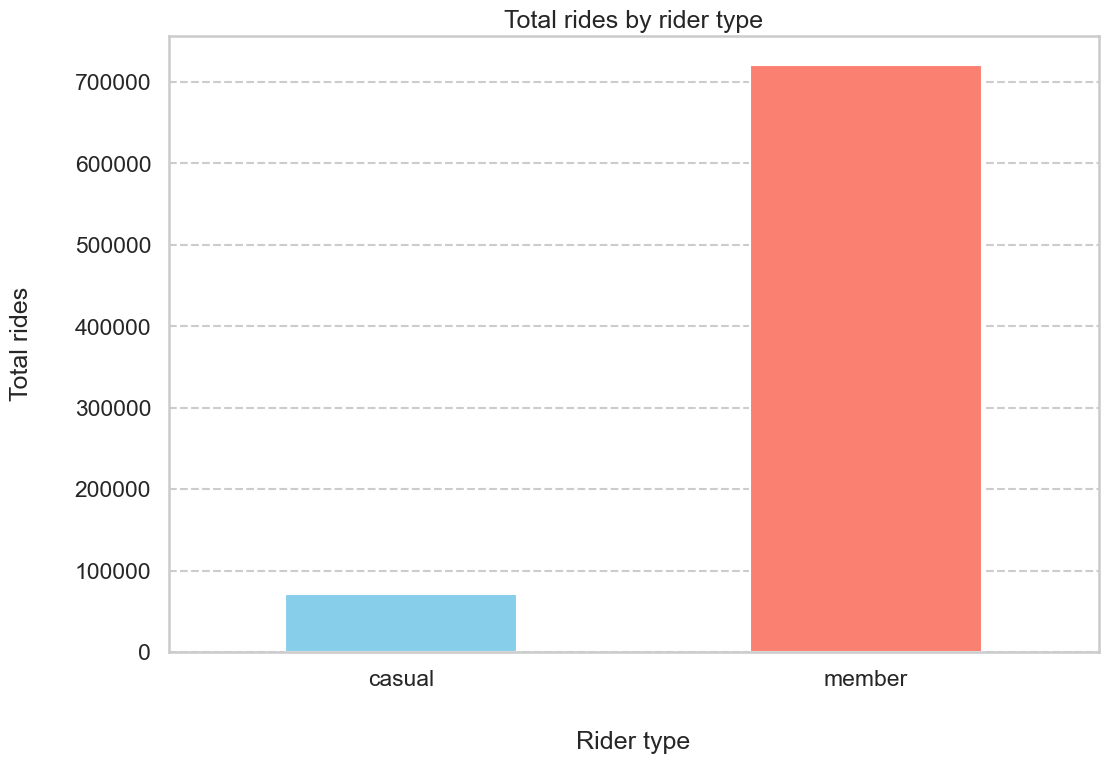

In [62]:
fig, ax = plt.subplots(figsize=(12, 8))
all_trips_percentaje.plot(
    kind='bar',
    x='member_casual',
    y='Total_rides',
    color=['skyblue', 'salmon'],
    legend=False,
    ax=ax
)
plt.title('Total rides by rider type')
plt.xlabel('Rider type', labelpad=30)
plt.ylabel('Total rides', labelpad=30)
plt.grid(axis= 'y', linestyle='--')
plt.gca().xaxis.grid(False)
plt.xticks(rotation=0)
plt.show()

<p style="text-align:justify">
This bar chart shows the total number of recorded rides by rider type. Members account for most rides in this dataset, while casual riders represent a much smaller share.
</p>

<Figure size 1200x800 with 0 Axes>

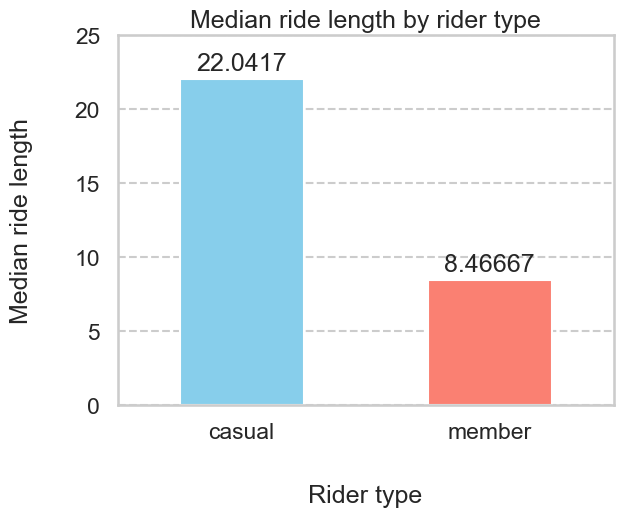

In [61]:
plt.figure(figsize=(12, 8))
ax = agg_data.plot(
    kind='bar',
    x='member_casual',
    y='median',
    legend=False,
    color=['skyblue', 'salmon']
)
plt.title('Median ride length by rider type')
plt.xlabel('Rider type', labelpad=30)
plt.ylabel('Median ride length', labelpad=30)
plt.grid(axis='y', linestyle='--')
plt.gca().xaxis.grid(False)
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=0)
plt.ylim(0, 25)
plt.show()

<p style="text-align:justify">
This chart shows the median ride length for each rider type. Casual riders have longer median ride durations than members, which suggests that they tend to use the service for longer trips.
</p>

In [52]:
ride_by_day_plot = ride_by_day.copy()
ride_by_day_plot['percentage_within_group'] = ride_by_day_plot['percentage_within_group'].str.replace('%', '', regex=False)
ride_by_day_plot['percentage_within_group'] = ride_by_day_plot['percentage_within_group'].astype(float)


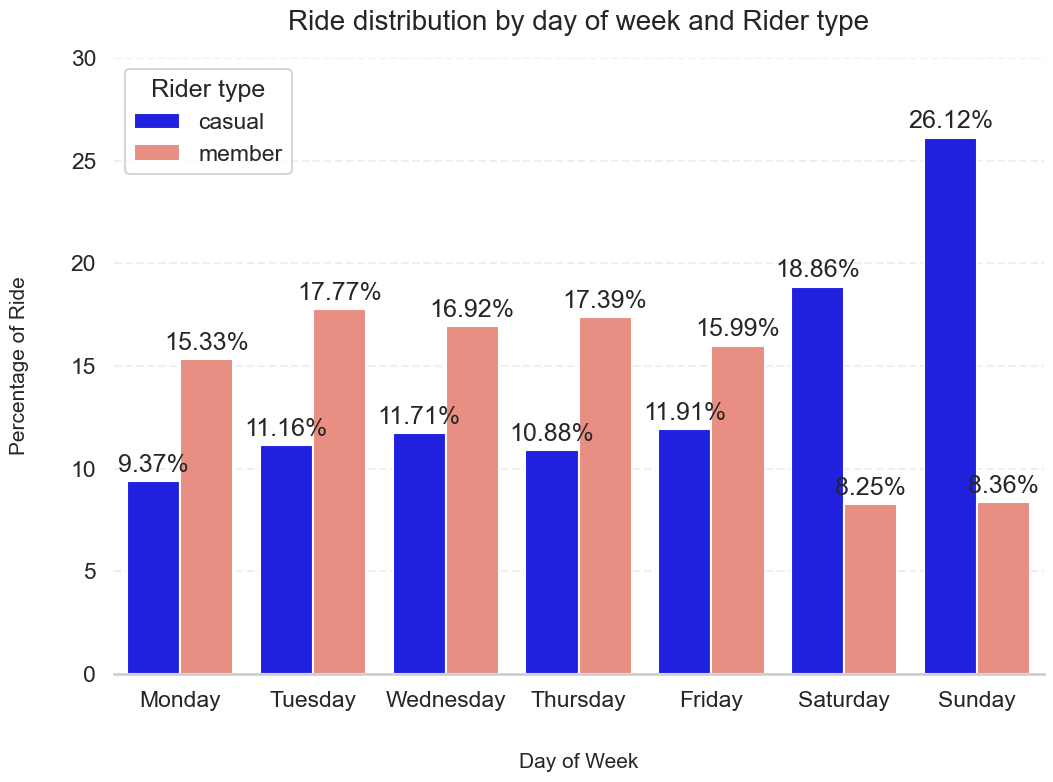

In [53]:
plt.figure(figsize=(12, 8))
sns.set_theme(style='whitegrid', context='talk', palette='pastel')
ax = sns.barplot(data=ride_by_day_plot, x='day_of_week', y='percentage_within_group', hue='member_casual', palette=['blue', 'salmon'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Ride distribution by day of week and Rider type', fontsize=20, pad=20)
plt.xlabel('Day of Week', labelpad=30, fontsize=15)
plt.ylabel('Percentage of Ride', labelpad=30, fontsize=15)
plt.legend(title='Rider type', loc='upper left')
plt.ylim(0,30)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True)
plt.show()

<p style="text-align:justify">
This chart shows the percentage of rides by day of the week for each rider type. Casual riders have a higher share of rides on weekends, while members have a higher share on weekdays. This suggests that casual riders use the service more for leisure, while members use it more for regular transportation.
</p>


In [56]:
ride_by_month_plot = ride_by_month.copy()
ride_by_month_plot['percentage_within_group'] = ride_by_month_plot['percentage_within_group'].str.replace('%', '', regex=False)
ride_by_month_plot['percentage_within_group'] = ride_by_month_plot['percentage_within_group'].astype(float)

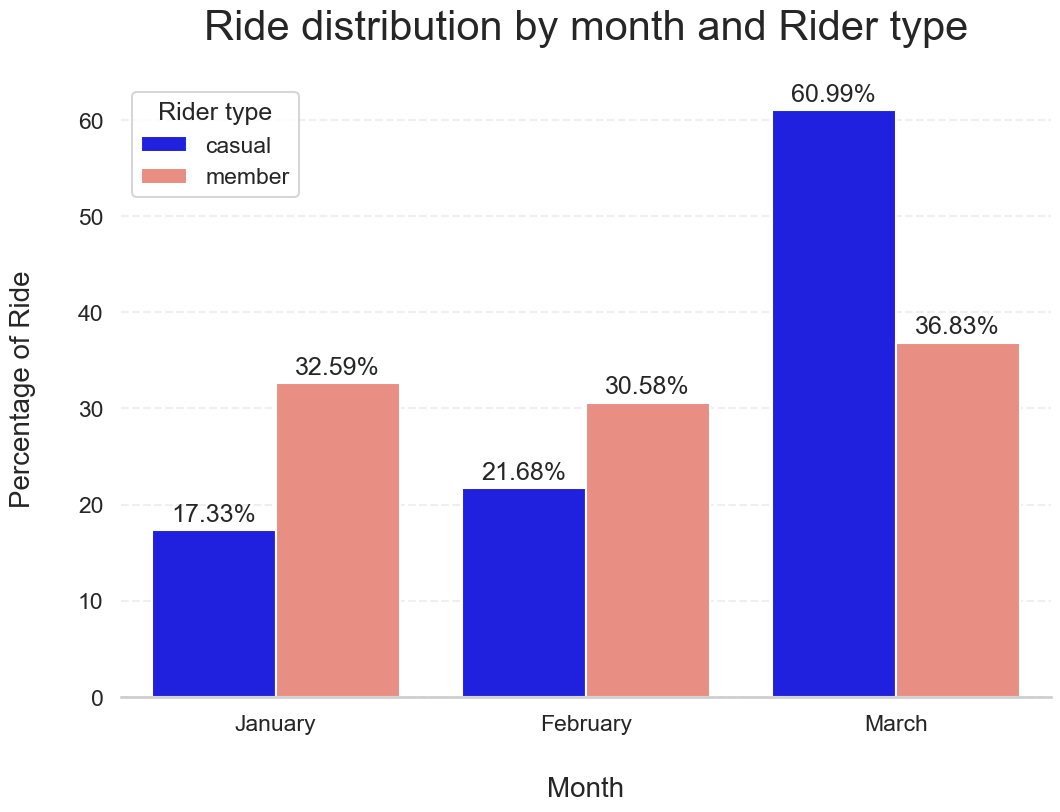

In [60]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=ride_by_month_plot,
    x='month',
    y='percentage_within_group',
    hue='member_casual',
    palette=['blue', 'salmon']
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Ride distribution by month and Rider type', fontsize=30, pad=30)
plt.xlabel('Month', labelpad=30, fontsize=20)
plt.ylabel('Percentage of Ride', labelpad=30, fontsize=20)
plt.legend(title='Rider type', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True)
plt.show()

<p style="text-align:justify">
This chart shows the percentage of rides by month for each rider type during the first quarter of the year. March has the highest share of rides for both casual riders and members in this dataset.
</p>

## Key Findings

- Most recorded rides in this dataset were taken by members.
- Casual riders had longer median ride durations than members.
- Casual riders showed a stronger weekend riding pattern.
- Members showed a stronger weekday riding pattern.
- March had the highest share of rides for both rider groups in the first quarter.

These findings suggest that members mainly use Cyclistic bikes for routine transportation, while casual riders are more likely to use them for longer and more leisure-oriented trips.

# Final Conclusions
<p style="text-align:justify">
The analysis shows clear behavioral differences between Cyclistic members and casual riders. Members account for most of the recorded rides in the dataset, but casual riders tend to take longer trips and ride more often on weekends. In contrast, members show a stronger weekday riding pattern, which suggests more routine transportation use. March also had the highest ride activity for both groups in the first quarter, which may indicate a seasonal pattern.
</p>

# Recommendations

- Since casual riders appear to use the service more for leisure and longer rides, the company could promote membership as a way to save money for frequent or extended use. Weekend-focused campaigns, seasonal promotions, and messages that highlight convenience and value could be especially effective for this group.
- The business should test targeted campaigns aimed at casual riders, especially during weekends and high-activity months. It would also be useful to compare member and casual behavior across more time variables, such as hour of day or trip start locations, to identify stronger patterns.
- Additional data from the rest of the year would help confirm whether the March increase is part of a seasonal trend. It would also be useful to have:
    * trip data from more months or years.
    * station-level popularity and route patterns
    * time-of-day usage data
    * pricing or pass-purchase data
    * customer survey or demographic data